## Basic Setup

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
model_name = '1_synthetic_eyes'
transfer_learning_stage = '0_last_layers'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/Unity_Data_Test_Train'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet'

In [5]:
comment = "hopefully final run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [6]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [7]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=30, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

In [8]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
Found 1000 files belonging to 2 classes.


## Training the Pre-Trained Model

In [9]:
def initialize_baseline_model(title, mn_output_layer, unfreeze_from_layer, loss_function, optimizer, dropout_rate, regularization_rate, input_shape=INPUT_SHAPE):

    # Load the MobileNetV2 model    
    pretrained_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

    pretrained_model.trainable = False

    # Unfreeze the layers starting from unfreeze_from_layer (exclusive)
    unfreeze = False
    for layer in pretrained_model.layers:
        if unfreeze:
            layer.trainable = True
        elif layer.name == unfreeze_from_layer:
            layer.trainable = False
            unfreeze = True

    # Ensure BN layers are in inference mode
    for layer in pretrained_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        
    # Get the desired output layer
    last_layer = pretrained_model.get_layer(mn_output_layer)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    # Functional API model construction
    x = base_model.output
    x = Flatten()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(regularization_rate))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(2, activation='softmax')(x)
    
    # Define the final model
    model = Model(inputs=base_model.input, outputs=outputs, name=title)

    # Compile the model
    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [10]:
model = initialize_baseline_model(title=model_name, mn_output_layer=MN_OUTPUT_LAYER, unfreeze_from_layer=UNFREEZE_FROM_LAYER, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

In [11]:
model.summary(show_trainable=True)

Model: "1_synthetic_eyes"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ input_layer_1… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 5,892,290 (22.48 MB)

 Trainable params: 4,048,258 (15.44 MB)

 Non-trainable params: 1,844,032 (7.03 MB)

In [12]:
history = model.fit(
    synth_train_data,
    validation_data=synth_valid_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr] # early_stop
    )

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5279 - loss: 7.9084
Epoch 1: val_accuracy improved from -inf to 0.67750, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/1_synthetic_eyes/0_last_layers/ckpt/hopefully final run_checkpoint.model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.5296 - loss: 7.9036 - val_accuracy: 0.6775 - val_loss: 7.3376 - learning_rate: 1.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7770 - loss: 7.2680
Epoch 2: val_accuracy improved from 0.67750 to 0.86750, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/1_synthetic_eyes/0_last_layers/ckpt/hopefully final run_checkpoint.model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7774 - loss: 7.2667 - val_accuracy: 0.8675 - val_loss: 7.0478 - learning_rate: 1.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8517 - loss:

In [13]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [14]:
# load the best model
model.load_weights(ckpt_file_path)

In [15]:
# save the model
model.save(model_file_path)

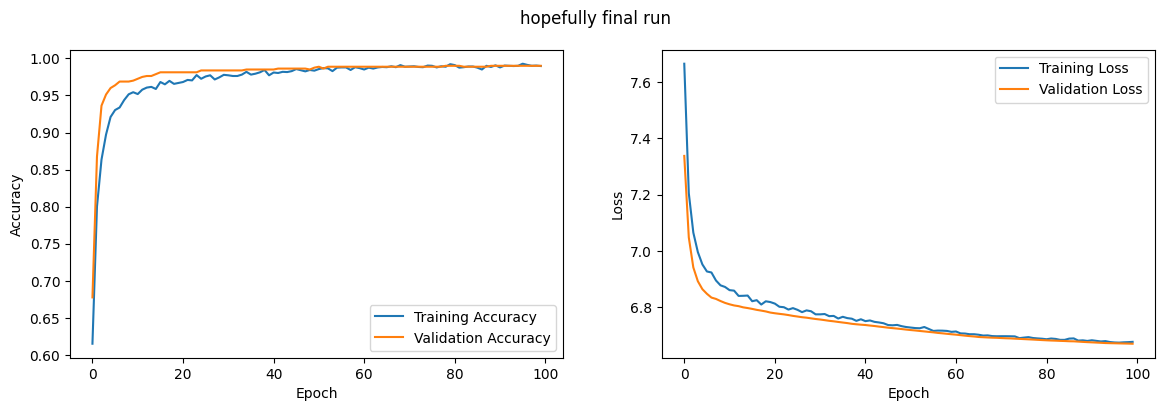

Best train_accuracy: 0.9928
Best train_loss: 6.6735
Best val_accuracy: 0.99
Best val_loss: 6.6697
Last improvement at epoch: 79


In [16]:
plot_history(comment, history)

2024-07-17 02:27:29.177642: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test accuracy: 0.988
Test precision: 0.998
Test recall: 0.978
Test F1 score: 0.988
Prediction time: 22.83 seconds


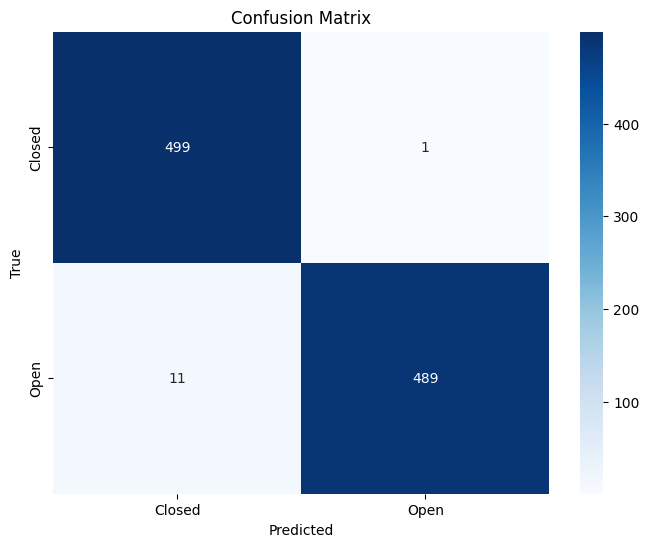

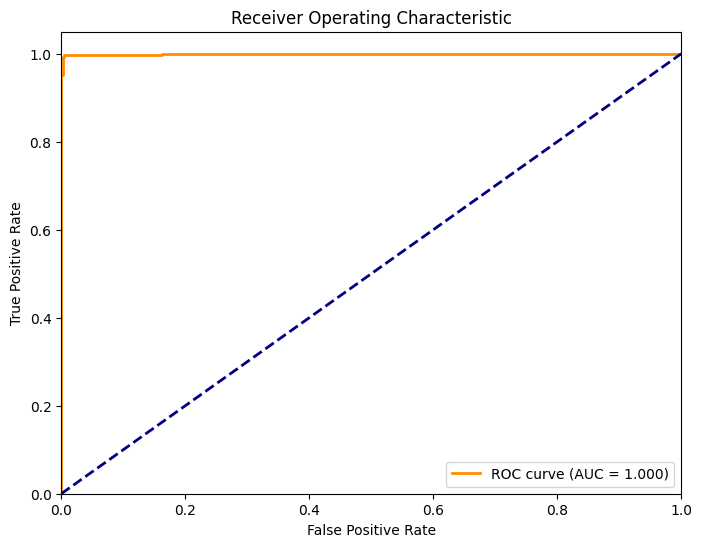

In [17]:
evaluate_model(model, synth_test_data)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.


2024-07-17 02:27:31.338397: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-07-17 02:27:32.788079: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-17 02:27:33.693533: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

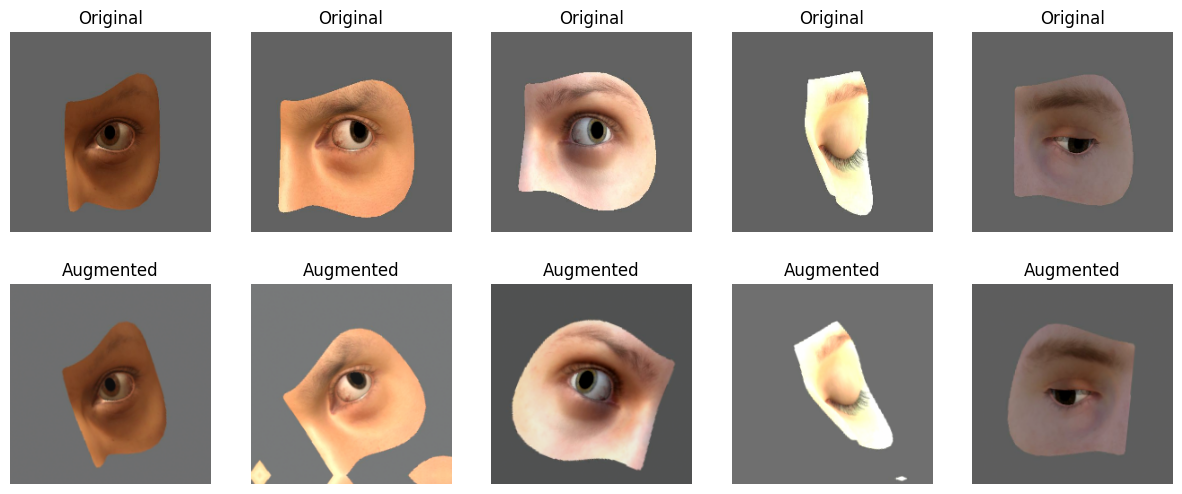

In [18]:
synth_train_data_augm = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2, skip_preprocessing=True)
synth_train_data_orig = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, skip_preprocessing=True)

plot_images(img_orig=synth_train_data_orig, img_augm=synth_train_data_augm)

Found 4000 files belonging to 2 classes.
Using 800 files for validation.


2024-07-17 02:27:34.866350: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 585ms/step


2024-07-17 02:27:37.188757: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


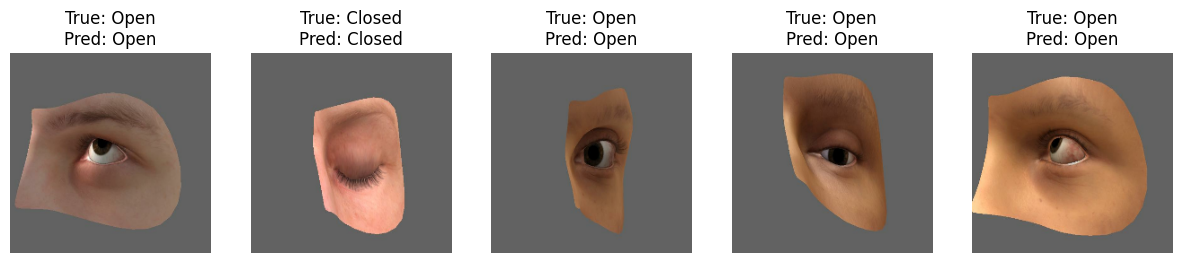

In [19]:
synth_valid_data_skip_preprocessing = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='validation', validation_split=0.2, skip_preprocessing=True)

plot_predictions(model=model, dataset=synth_valid_data, dataset_visual=synth_valid_data_skip_preprocessing)